# Volume analysis on images from pipeline MNISym_coreg_normalize

dataframe TBA...

Using images: T1 anatomical, segmentations (GM, WM, CSF), log det(Jac).

Volume (mean, median, sum) in ROIs defined by the atlas `Diedrichsen_2009` (original SUIT atlas) with anatomical labels.

# notes; ignore

## need to make the summarized_df stuff cleaner - rn we have one for subj_unique (not so aptly named) and another for weeks.
Fix this, re-run with cleaner code, and use that as the actual df in this



Just use the function `make_summarized_dataframe`.

Will run this function from the script for the pipeline `MNISym_coreg_normalize` (go to that script to make the dataframe).


## need to add dataframe from this - this is JUST for normalized images (no regression done).

So we will be analyzing: contra-, ipsi-lesional hemispheres, vermis, controls; lesions are left in their original side (no flipping).

We will have:
    for each subject: for each week: volume in each ROI; this is for each of the five images above.

In [47]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import smarts_cerebellum.globals as gl

from pathlib import Path
import os

In [48]:
p_df = pd.read_csv(f'{gl.baseDir}/participants_anat.tsv', sep = '\t')

In [49]:
df = pd.read_csv(f'{gl.baseDir}/MNISym_WM/MNISym_coreg_WM_normalized_AtlasSUIT_summarized.tsv', sep = '\t')

In [50]:
df['hemisphere'] = df['regionname'].str[0]

# subjects with W0
diff_df = pd.DataFrame()

for subj in df['subj_id'].unique():
    refT1 = (df.loc[(df['subj_id']==subj), 'RefT1'].iloc[0]).strip()
    if not refT1=='W0':
        print(subj, "skipped")
        continue
    diff_df = pd.concat([diff_df, df[df['subj_id']==subj]])

CU_2697 skipped
JHU_2282 skipped
JHU_2577 skipped
JHU_2684 skipped
JHU_3176 skipped
UZ_2365 skipped
UZ_2450 skipped
UZ_2595 skipped
UZ_3030 skipped
UZ_3224 skipped
UZ_3228 skipped


In [51]:
diff_df.columns

Index(['image', 'image_name', 'frame', 'region', 'regionname', 'volume',
       'atlas', 'map', 'space', 'mean', 'median', 'nansum', 'subj_id', 'ID',
       'Centre', 'RefT1', 'Week', 'week', 'age', 'Gender', 'isPatient',
       'LesionSide', 'LesionLocation', 'handedness', 'hemisphere'],
      dtype='object')

In [52]:
# total wmv per week

week_vols = diff_df.groupby(['subj_id', 'week', 'Week', 'isPatient', 
                             'hemisphere', 'LesionSide', 'LesionLocation', 'RefT1']
                             ).agg({'nansum': 'sum'}
                             ).reset_index()

In [53]:
# change in total WM volume relative to the first week per hemisphere (left, right, vermis)

#for subj in week_vols.loc[week_vols['isPatient']==1, 'subj_id'].unique():
for subj in week_vols['subj_id'].unique():
    for week in week_vols.loc[week_vols['subj_id']==subj, 'Week'].unique():
        for hem in week_vols.loc[week_vols['subj_id']==subj, 'hemisphere'].unique():
            curr_vol = week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['Week'] == week) & (week_vols['hemisphere'] == hem), 'nansum'].iloc[0]

            ref_vol = week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['Week'] == refT1) & (week_vols['hemisphere'] == hem), 'nansum'].iloc[0]
            week_vols.loc[(week_vols['subj_id'] == subj) & (week_vols['Week'] == week) & (week_vols['hemisphere'] == hem), 'vol_diff'] = curr_vol - ref_vol

In [54]:
week_vols

,subj_id,week,Week,isPatient,hemisphere,LesionSide,LesionLocation,RefT1,nansum,vol_diff
0,CUP_1001,0.0,W0,0.0,L,none,none,W0,9682.414271,0.000000
1,CUP_1001,0.0,W0,0.0,R,none,none,W0,9930.276166,0.000000
2,CUP_1001,0.0,W0,0.0,V,none,none,W0,602.761635,0.000000
3,CUP_1001,4.0,W4,0.0,L,none,none,W0,7268.660101,-2413.754170
4,CUP_1001,4.0,W4,0.0,R,none,none,W0,7061.243062,-2869.033104
...,...,...,...,...,...,...,...,...,...,...
517,UZ_3248,24.0,W24,1.0,R,left,subcortical,W0,6540.545869,-119.156716
518,UZ_3248,24.0,W24,1.0,V,left,subcortical,W0,488.140823,0.678197
519,UZ_3248,52.0,W52,1.0,L,left,subcortical,W0,7327.588350,207.582704
520,UZ_3248,52.0,W52,1.0,R,left,subcortical,W0,6346.911258,-312.791327


In [55]:
# create dummy column: ipsilesional = 0, contralesional = 1, none = 3 (no stroke), vermis = 2

hem_dict = {
    'L': 'left',
    'R': 'right',
    'V': 'vermis'
}

week_vols['hemisphere'] = week_vols['hemisphere'].map(hem_dict) # hem names should match LesionSide names
# we can use this naming convention in all subsequent cells, so it's fine

lesion_namings = {'L': 'left', 'R': 'right', 'l': 'left', 'r': 'right',
              'Left': 'left', 'Right': 'right', 'left': 'left', 'right': 'right'}
week_vols['LesionSide'] = week_vols['LesionSide'].astype(str).str.strip()

week_vols['side_type'] = 3 # default none

# for patient rows: set ipsi-, contra-lesional, vermis
mask_patient = week_vols['isPatient']==1
mask_hemi_lr = week_vols['hemisphere'].isin(['left', 'right']) # for l, r hem, assign ipsilesional or contralesional

week_vols.loc[mask_patient & (week_vols['hemisphere'] == week_vols['LesionSide']), 'side_type'] = 0 # ipsi
week_vols.loc[mask_patient & mask_hemi_lr & (week_vols['hemisphere'] != week_vols['LesionSide']), 'side_type'] = 1 # contra
week_vols.loc[mask_patient & (week_vols['hemisphere'] == 'vermis'), 'side_type'] = 2 # vermis

In [56]:
# put descriptive titles on plots
titles = {
    '0': 'ipsilesional',
    '1': 'contralesional',
    '3': 'control',
    '2': 'vermis'
}

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


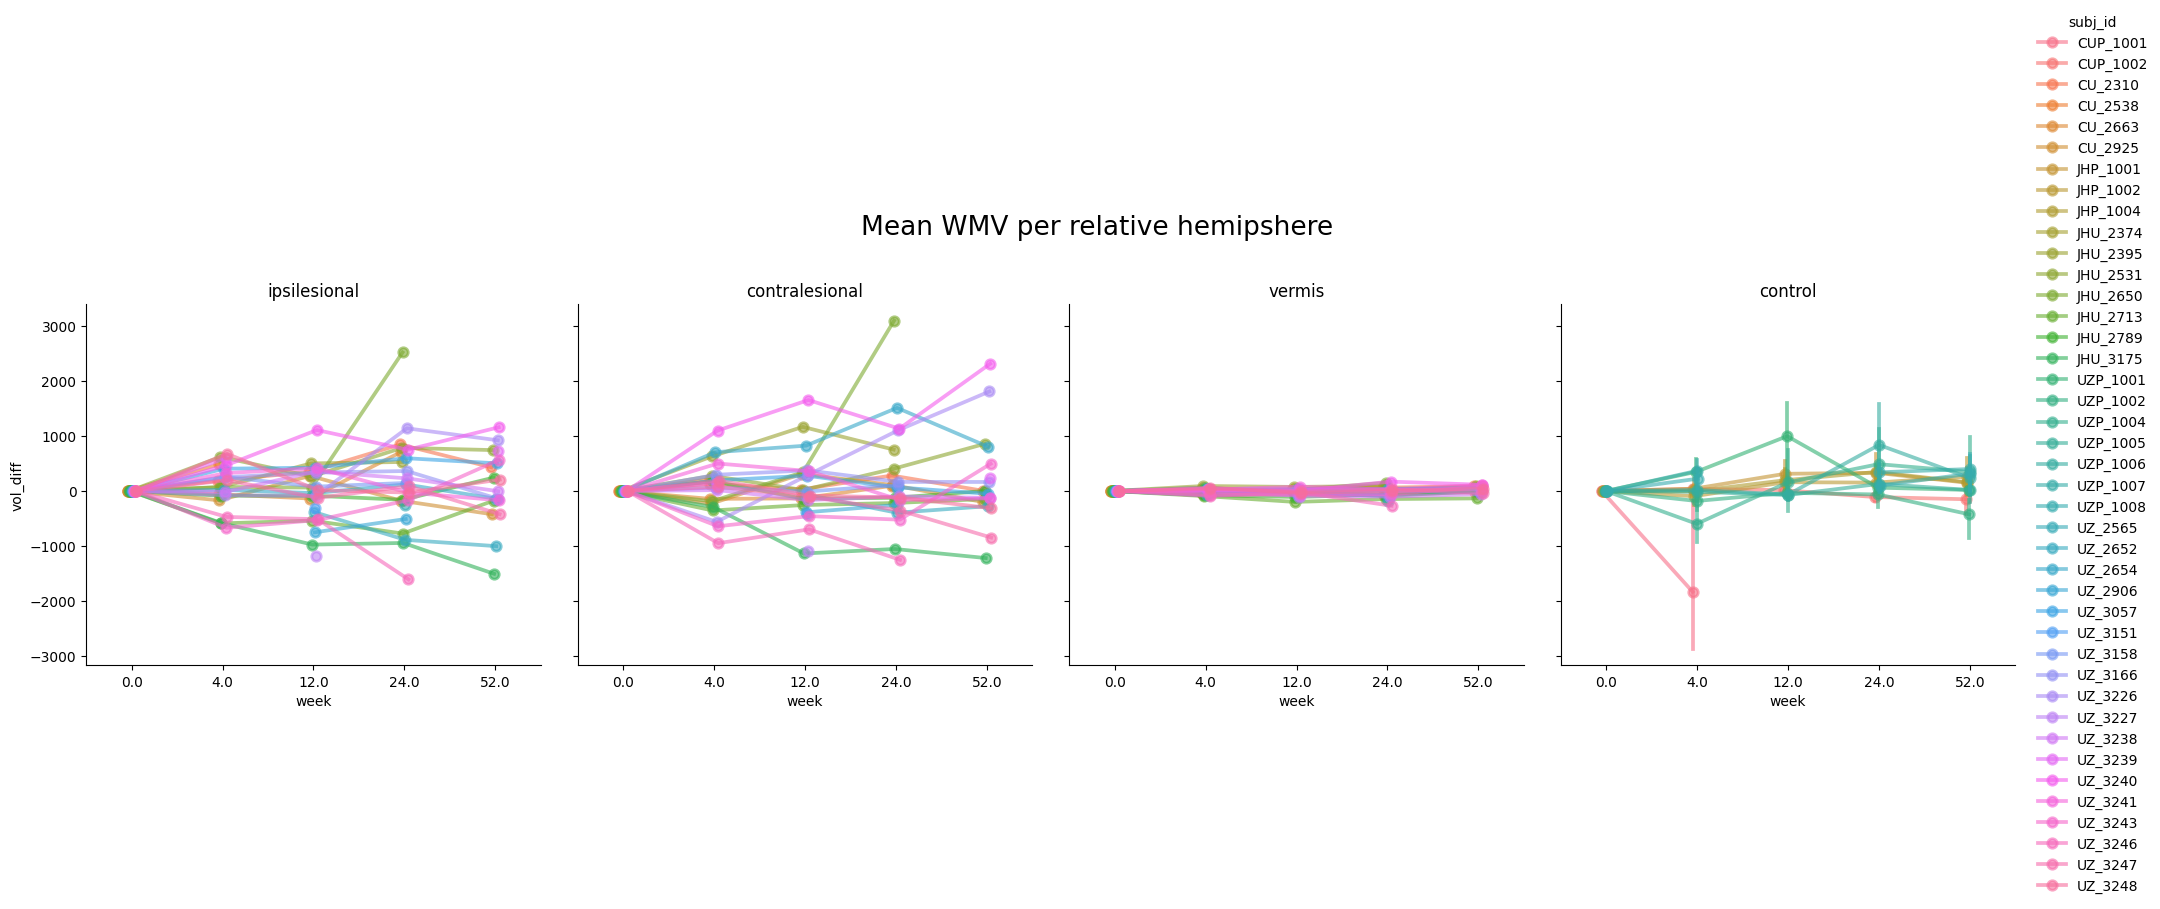

In [57]:
diff_plots_wmv_mean = sns.catplot(data = week_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_mean.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_mean.figure.suptitle('Mean WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_mean.figure.subplots_adjust(top = 0.8)
plt.show()
# vermis is coded as '2', gets its own plot

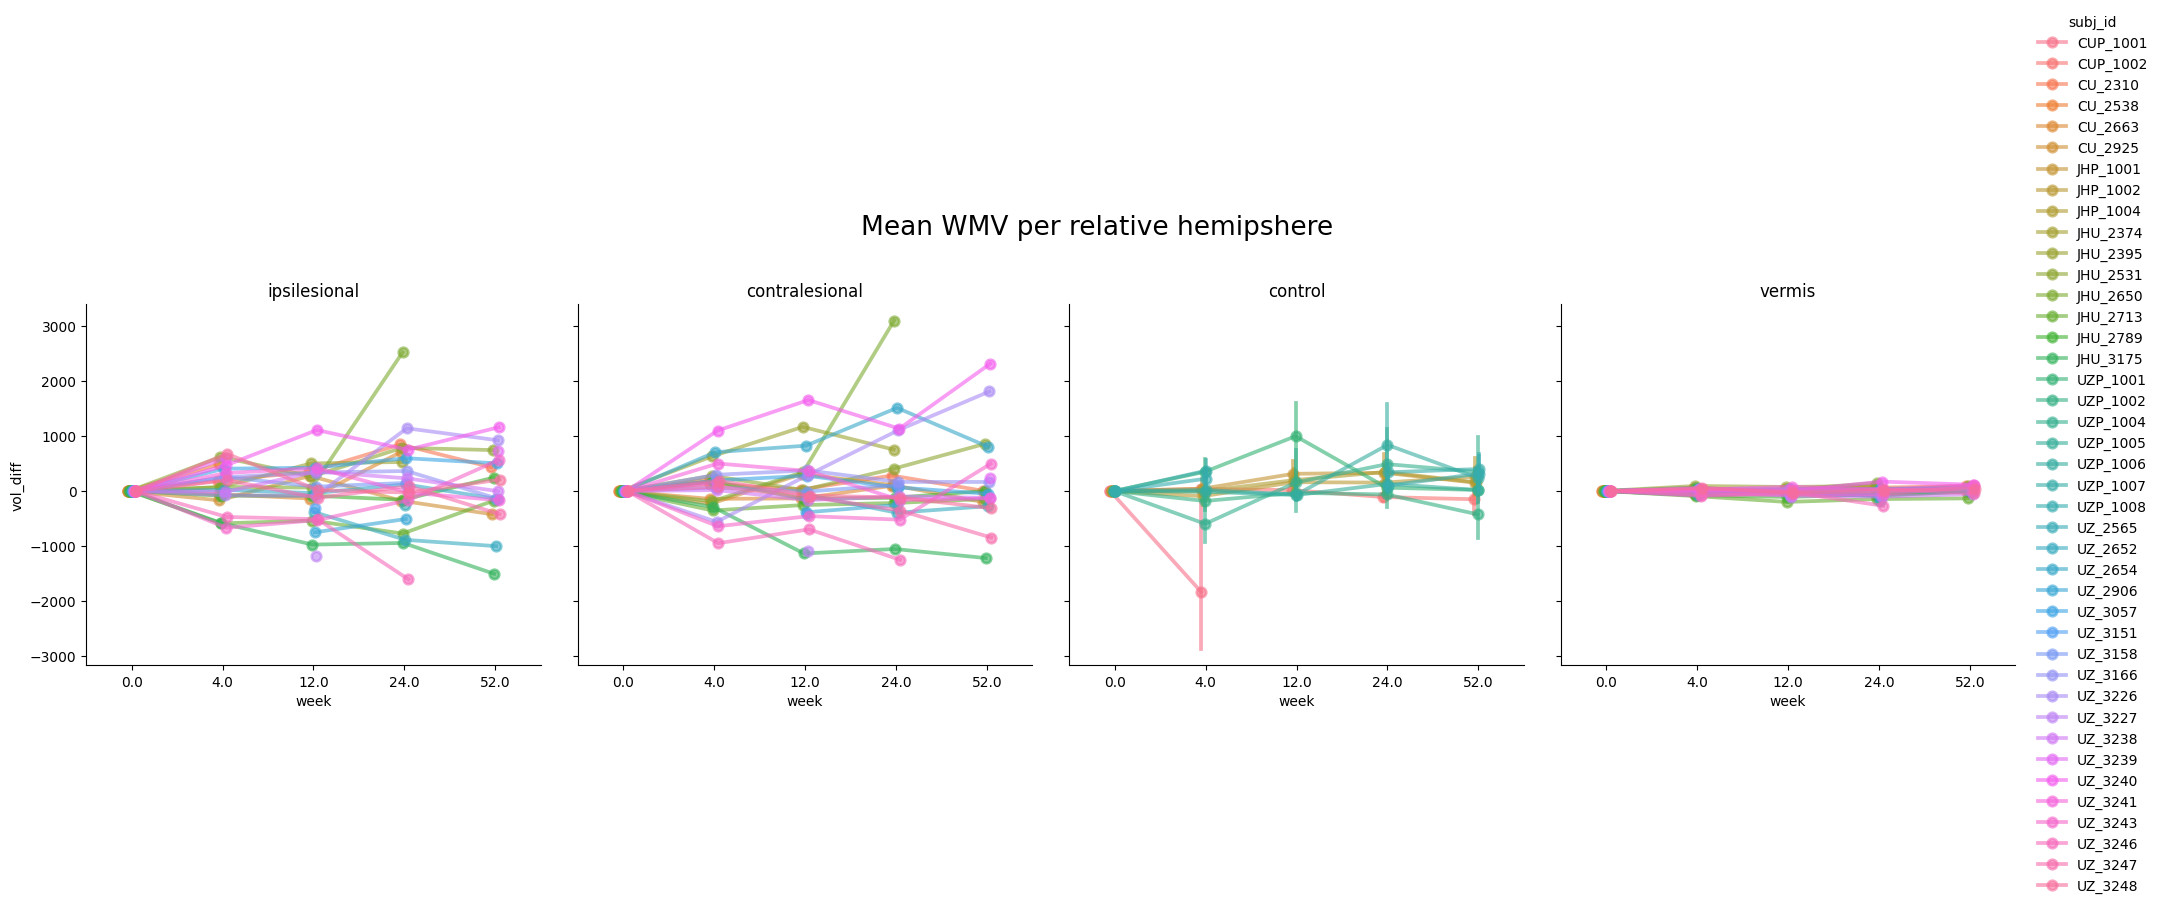

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


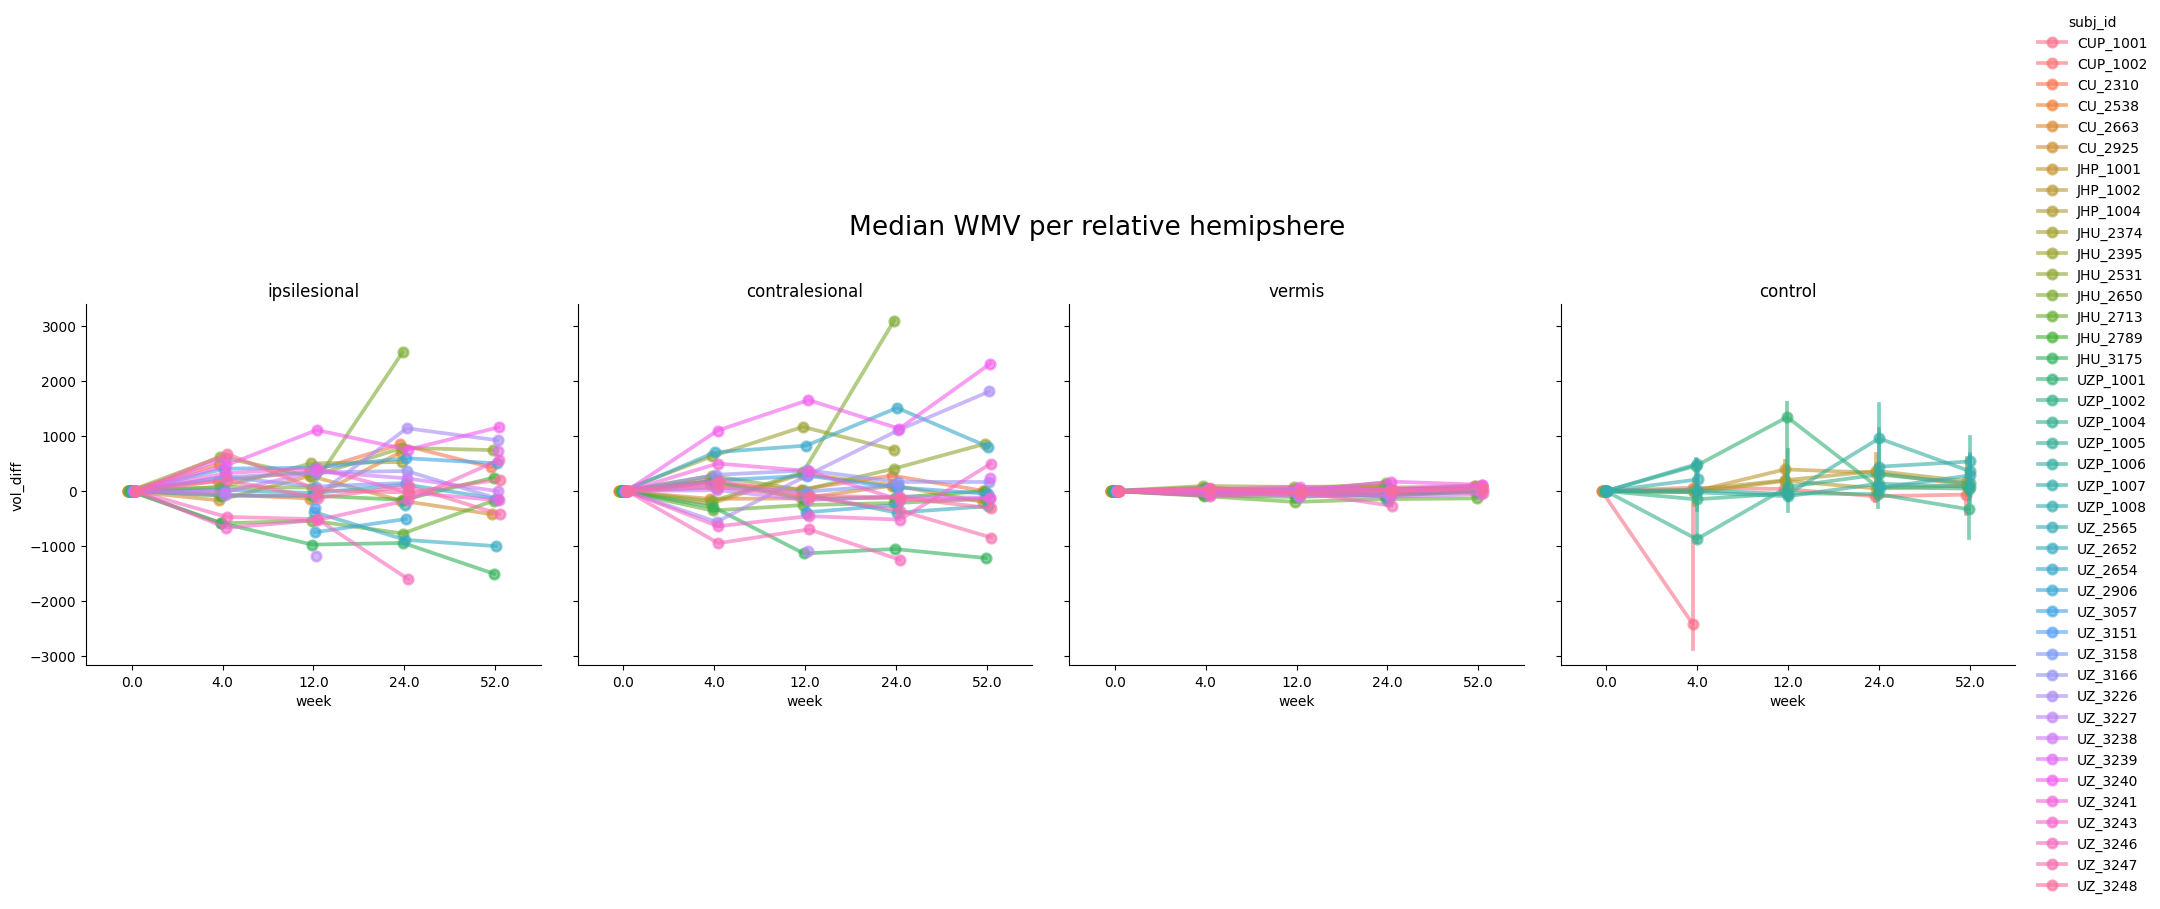

In [58]:
# plot the medians
diff_plots_wmv_median = sns.catplot(data = week_vols,
            x='week', y='vol_diff',
            hue = 'subj_id', col = 'side_type',
            kind = 'point',
            estimator = 'median',
            alpha = 0.6, dodge = 0.1
            )

for ax in diff_plots_wmv_median.axes.flat:
    previous_title = ax.get_title()
    value = (previous_title.split('=')[1]).strip() # get dummy value
    ax.set_title(titles[value])

diff_plots_wmv_median.figure.suptitle('Median WMV per relative hemipshere', fontsize = 19)
diff_plots_wmv_median.figure.subplots_adjust(top = 0.8)
plt.show()

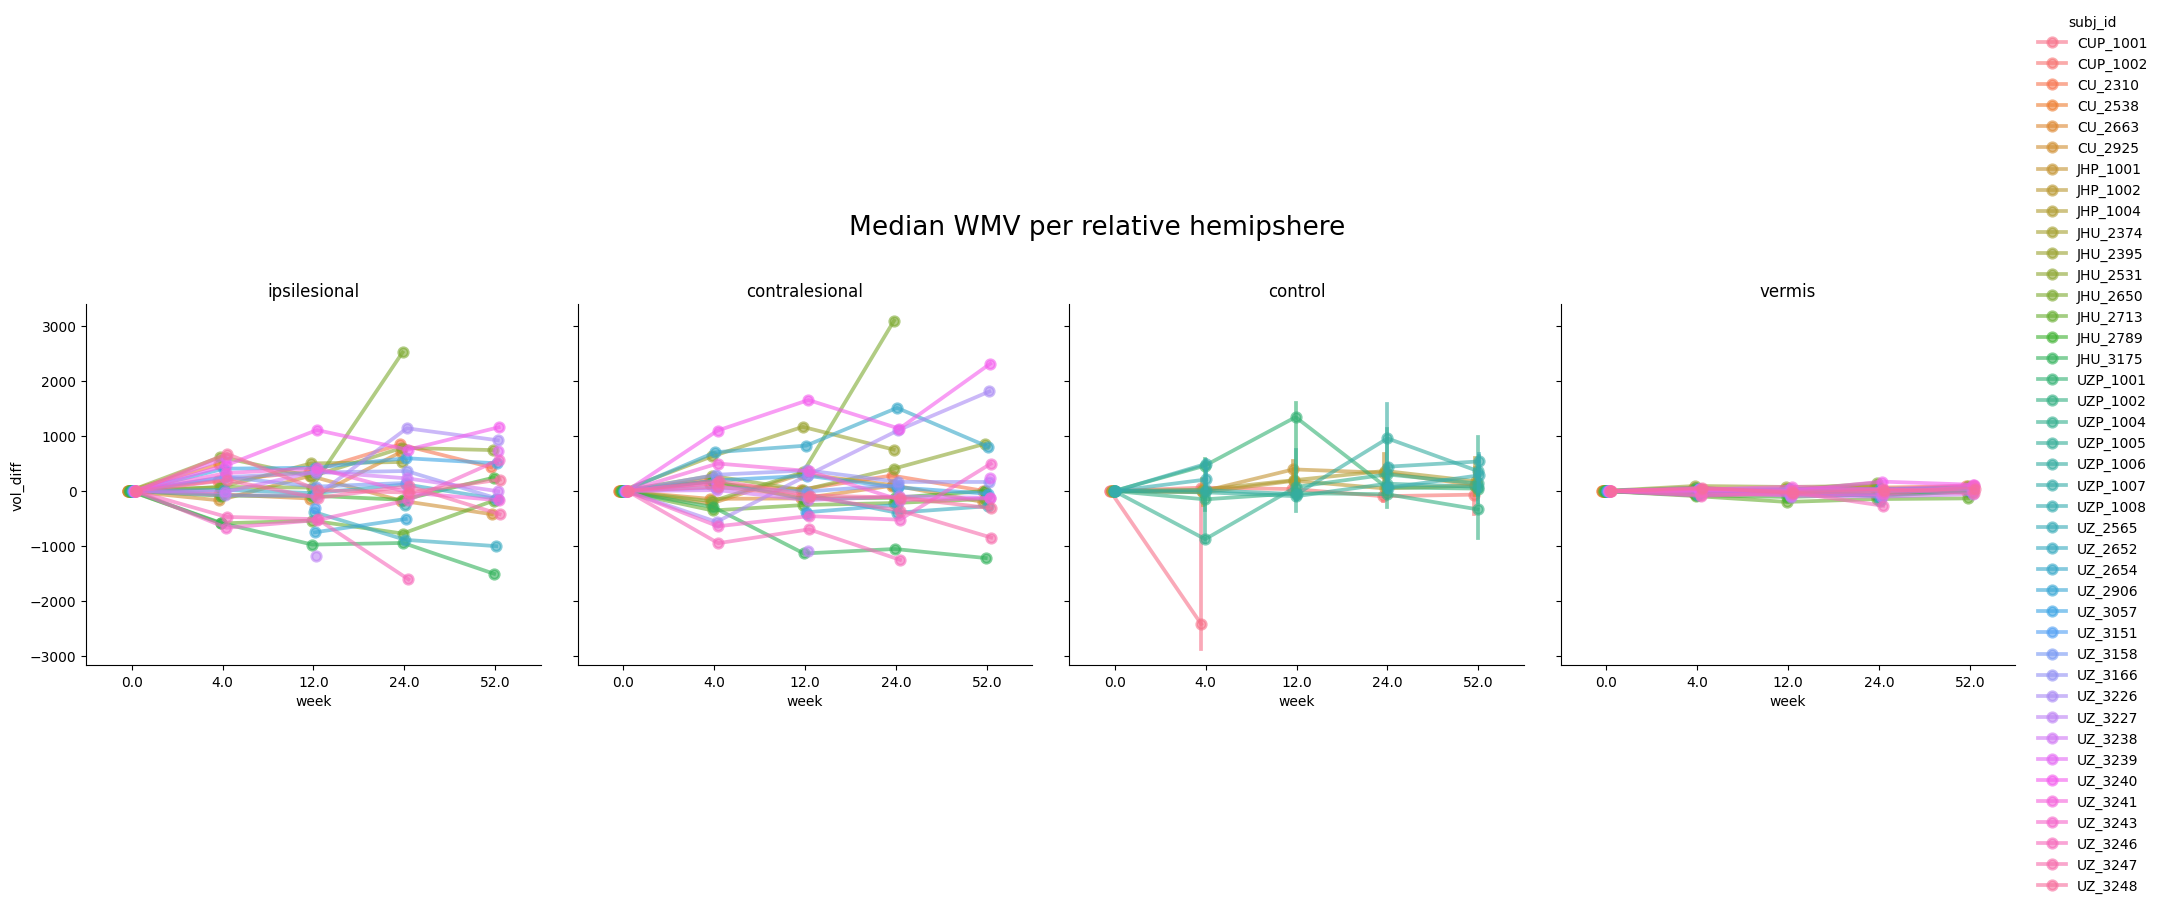

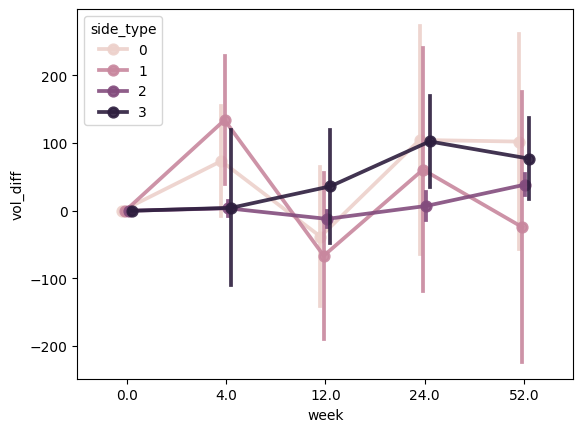

In [61]:
sns.pointplot(data = week_vols, x='week', y='vol_diff', hue = 'side_type', errorbar = 'se', estimator = 'median', dodge = 0.1, alpha = 0.9)
plt.show()